In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl

from pipelines import cat_cols, num_cols, binary_cols, ord_cols, clean_data, engineer_X, bool_target
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import PartialDependenceDisplay

In [29]:
X_train = pd.read_csv("../data/processed/X_train.csv", index_col=0)
y_train = pd.read_csv("../data/processed/y_train.csv", index_col=0)

X_test = pd.read_csv("../data/processed/X_test.csv", index_col=0)
y_test = pd.read_csv("../data/processed/y_test.csv", index_col=0)

In [30]:
# Apply cleaning, feature engineering, and target encoding to both splits.
X_train = engineer_X(clean_data(X_train))
X_test = engineer_X(clean_data(X_test))

y_train = bool_target(y_train)
y_test = bool_target(y_test)

# Random Forest with Hyperparameter tuning

In [33]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('ord', OrdinalEncoder(categories=[[1, 2, 3, 4]]), ord_cols), 
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('bin', 'passthrough', binary_cols)
])

rf = RandomForestClassifier(class_weight='balanced', # to compensate for resampling
                            random_state=0)

param_grid = {
      'clf__n_estimators': [50, 100, 150],                               
      'clf__max_depth': [None, 10, 20],                                   
      'clf__min_samples_split': [2, 5, 7],
      'clf__min_samples_leaf': [8, 10, 12, 16],
  }

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', rf)
])

grid_search = GridSearchCV(estimator=rf_pipeline,
                           param_grid=param_grid,
                           scoring='f1',
                           cv=5,
                           n_jobs=-1,
                           verbose=1)


In [11]:
grid_search.fit(X_train, y_train.values.ravel())

print("Best params:", grid_search.best_params_)
print(f"Best CV F1:  {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 16, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
Best CV F1:  0.7224


In [12]:
y_pred = grid_search.predict(X_test)
y_prob = grid_search.predict_proba(X_test)[:, 1]

print(f"Random Forest with Hyperparameter tuning Performance:\n")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, 
                                      y_prob):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

Random Forest with Hyperparameter tuning Performance:

F1 Score: 0.7500
ROC-AUC Score: 0.8500
Precision: 0.6471
Recall: 0.8919


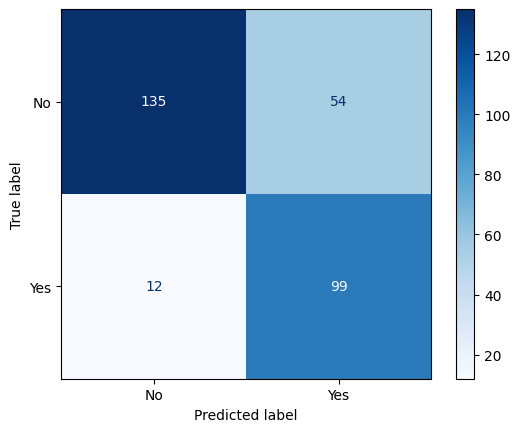

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, 
                      y_pred, 
                      labels=[0, 1])

disp = ConfusionMatrixDisplay(cm, 
                              display_labels=['No', 'Yes']).plot(cmap='Blues')


In [14]:
# prepare a list to append results
results = []
results.append({
    'Model':'Random Forest',
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred)
})

# XGBoost

In [15]:
# to reuse preprocessor from random forest
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('ord', OrdinalEncoder(categories=[[1, 2, 3, 4]]), ['Cancer_Stage_Numeric']), 
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('bin', 'passthrough', binary_cols)
])

xgb = XGBClassifier(random_state=0,
                    eval_metric='logloss',
                    verbosity=0)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', xgb)])

param_grid_xgb = {
      'clf__n_estimators': [200, 250, 300],
      'clf__max_depth': [1, 3, 5],
      'clf__learning_rate': [0.001, 0.01, 0.1],
      'clf__subsample': [0.8, 1.0],
      'clf__colsample_bytree': [0.8, 1.0],
  }

xgb_grid_search = GridSearchCV(estimator=xgb_pipeline,
                               param_grid=param_grid_xgb,
                               scoring='f1',
                               cv=5,
                               n_jobs=-1,
                               verbose=1)

In [16]:
xgb_grid_search.fit(X_train, y_train.values.ravel())

print("Best params:", xgb_grid_search.best_params_)     
print(f"Best CV F1: {xgb_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 250, 'clf__subsample': 1.0}
Best CV F1: 0.6848


In [17]:
y_pred = xgb_grid_search.predict(X_test)
y_prob = xgb_grid_search.predict_proba(X_test)[:, 1]

print(f"XGBoost Performance:\n")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, 
                                      y_prob):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

XGBoost Performance:

F1 Score: 0.7381
ROC-AUC Score: 0.8535
Precision: 0.6596
Recall: 0.8378


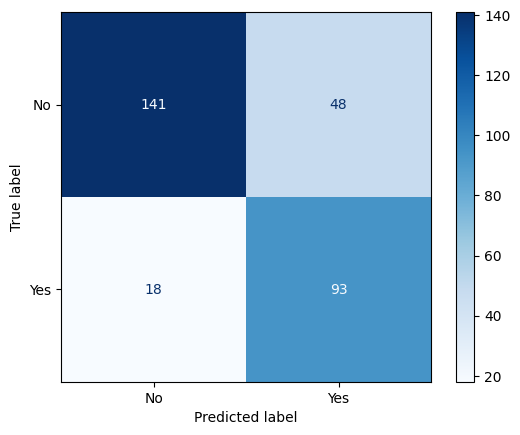

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, 
                      y_pred, 
                      labels=[0, 1])

disp = ConfusionMatrixDisplay(cm, 
                              display_labels=['No', 'Yes']).plot(cmap='Blues')


In [19]:
# prepare a list to append results
results.append({
    'Model':'XGBoost',
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred)
})

# Logistic Regression 

In [20]:
from math import e


lr = LogisticRegression(random_state=0,
                        class_weight='balanced',
                        max_iter=1000)

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', lr)
])

param_grid_lr = {                                             
      'clf__C': [0.01, 0.1, 1, 10],                  
      'clf__penalty': ['l1', 'l2'],                       
      'clf__solver': ['liblinear', 'saga'],
  }  

lr_grid_search = GridSearchCV(lr_pipeline,
                              param_grid_lr,
                              scoring='f1',
                              cv=5,
                              n_jobs=-1,
                              verbose=1)



In [21]:
lr_grid_search.fit(X_train, y_train.values.ravel())

print("Best params.:", lr_grid_search.best_params_)
print(f"Best CV F1: {lr_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params.: {'clf__C': 0.01, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Best CV F1: 0.7231


In [22]:
y_pred = lr_grid_search.predict(X_test)
y_prob = lr_grid_search.predict_proba(X_test)[:, 1]

print(f"Logistic Regression Performance:\n")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, 
                                      y_prob):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

Logistic Regression Performance:

F1 Score: 0.7416
ROC-AUC Score: 0.8443
Precision: 0.6346
Recall: 0.8919


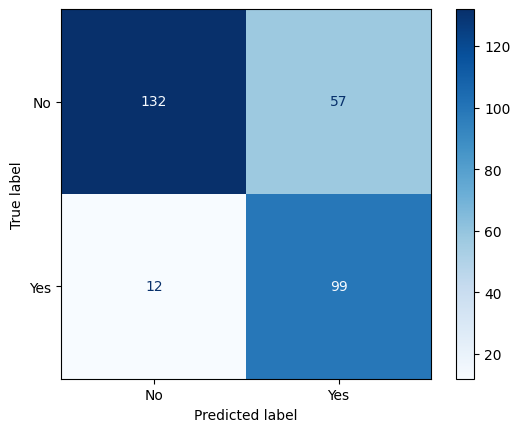

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, 
                      y_pred, 
                      labels=[0, 1])

disp = ConfusionMatrixDisplay(cm, 
                              display_labels=['No', 'Yes']).plot(cmap='Blues')


In [24]:
# prepare a list to append results
results.append({
    'Model':'Logistic Regression',
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred)
})

In [25]:
# displaying results as a dataframe
df_results = pd.DataFrame(results).set_index('Model').round(4)
df_results

,F1,ROC-AUC,Precision,Recall
Model,,,,
Random Forest,0.7500,0.8500,0.6471,0.8919
XGBoost,0.7381,0.8535,0.6596,0.8378
Logistic Regression,0.7416,0.8443,0.6346,0.8919


### Model Selected: Random Forest
- has the best F1 score overall.
- catching more true positives matters in clinical research, has high recall score

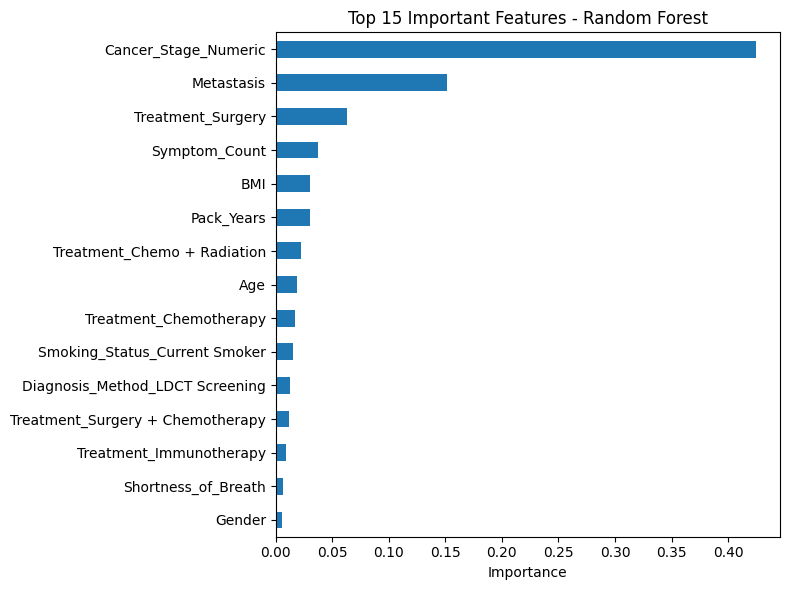

In [ ]:
# visualising feature importance
best_rf = grid_search.best_estimator_

X_names = (
    num_cols + 
    ['Cancer_Stage_Numeric'] + 
    list(best_rf.named_steps['preprocessor'].named_transformers_['cat']
         .get_feature_names_out(cat_cols))
         + binary_cols)

importances = best_rf.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=X_names).sort_values(ascending=False)

feat_imp.head(15).plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title('Top 15 Important Features - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

c:\Users\Jaeden Capinig\Documents\DPP-Projekt\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 31 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\Jaeden Capinig\Documents\DPP-Projekt\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 27 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\Jaeden Capinig\Documents\DP

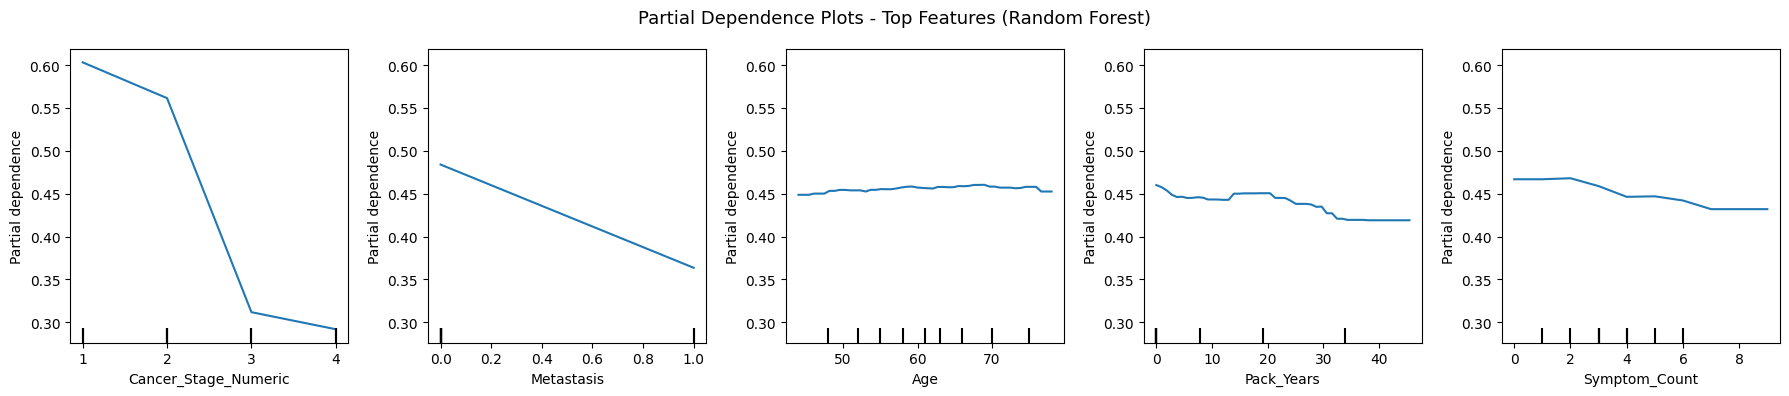

In [26]:
# top features 
top_features = ['Cancer_Stage_Numeric', 'Metastasis', 'Age',
                'Pack_Years', 'Symptom_Count']

fig, axes = plt.subplots(1, len(top_features), figsize=(18, 4))

PartialDependenceDisplay.from_estimator(
    grid_search,
    X_train,
    features=top_features,
    kind='average',
    ax=axes,
    grid_resolution=50
  )

plt.suptitle('Partial Dependence Plots - Top Features (Random Forest)', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
with open('../data/processed/best_rf_model.pkl', 'wb') as f:
    pkl.dump(grid_search.best_estimator_, f)